<a href="https://colab.research.google.com/github/shahnawaz-ui/shahnwazpatel_AIDSSEM8_RL_EXP/blob/main/Copy_of_RL_EXP_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**shahnawaz patel / 232A012 / 32 / RL EXP 03**

**Implementing a basic grid-world environment as an MDP and applying policy iteration**

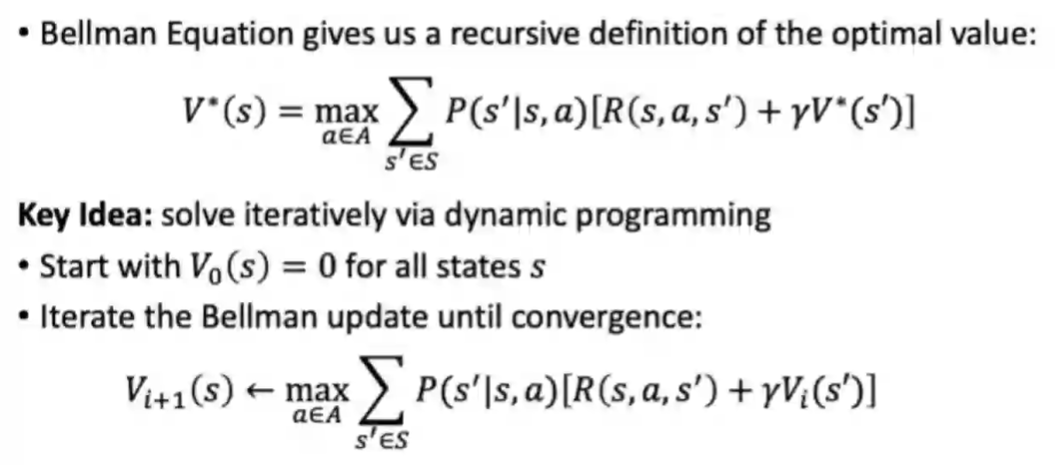![image.png]( )

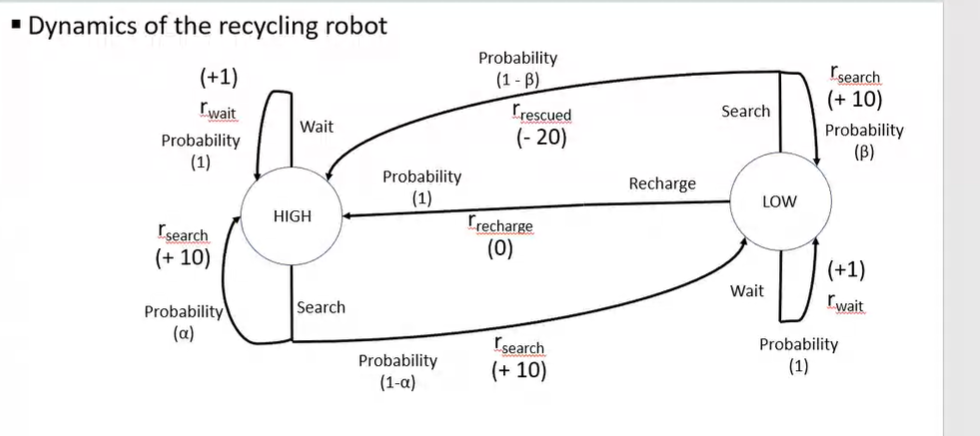

In [ ]:
print("shahnawaz patel / 232A012 / 32 ")
def value_iteration(states, actions, transition_model, reward_function, gamma, epsilon):
  #Initialize value function
  V={s: 0 for s in states}

  while True:
    delta=0
    for s in states:
      v=V[s]
      V[s] = max(sum(transition_model(s, a, s_next) *
                       (reward_function(s, a, s_next) + gamma * V[s_next])
                        for s_next in states) for a in actions)
      delta = max(delta, abs(v - V[s]))
    #Check for convergence
    if delta < epsilon:
      break
  #Extract optimal policy
  policy = {}
  for s in states:
    policy[s] = max(actions,
                    key=lambda a: sum(
                        transition_model(s, a, s_next) *
                                                 (reward_function(
                                                    s, a, s_next) + gamma * V[s_next])
                                                for s_next in states))
  return policy, V


shahnawaz patel / 232A012 / 32 


In [ ]:
print("shahnawaz patel / 232A012 / 32 ")
import numpy as np

shahnawaz patel / 232A012 / 32 


In [ ]:
print("shahnawaz patel / 232A012 / 32")
grid_size = (4, 4)
states = [(i, j) for i in range(grid_size[0]) for j in range(grid_size[1])]
actions= ['up', 'down', 'left', 'right']

shahnawaz patel / 232A012 / 32


In [ ]:
print("shahnawaz patel / 232A012 / 32 ")
states

shahnawaz patel / 232A012 / 32 


[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (3, 0),
 (3, 1),
 (3, 2),
 (3, 3)]

In [ ]:
print("shahnawaz patel / 232A012 / 32 ")
rewards= {(0, 0): 0, (3, 3):1}
terminal_states = [(0, 0), (3, 3)]

shahnawaz patel / 232A012 / 32 


In [ ]:
print("shahnawaz patel / 232A012 / 32 ")
rewards= {(0, 0): 0, (3, 3):1}
terminal_states = [(0, 0), (3, 3)]

#Transition probabilities
def transition(state, action):
    if state in terminal_states:
        return {state: 1.0}

    i, j = state
    if action == 'up':
        next_state = (max(i - 1, 0), j)
    elif action == 'down':
        next_state = (min(i + 1, grid_size[0] - 1), j)
    elif action == 'left':
        next_state = (i, max(j - 1, 0))
    elif action == 'right':
        next_state = (i, min(j + 1, grid_size[1] - 1))
    else:
        next_state = state # Stay in the same state if action is invalid

    if next_state in terminal_states:
        return {next_state: 1.0}
    else:
        return {next_state: 1.0}

shahnawaz patel / 232A012 / 32 


In [ ]:
print("shahnawaz patel / 232A012 / 32 ")
# Policy Iteration Algorithm
def policy_iteration(states, actions, gamma=0.9, theta=1e-6):
    policy = {s: np.random.choice(actions) for s in states if s not in terminal_states}
    V = {s: 0 for s in states}

    while True:
        # Policy Evaluation
        while True:
            delta = 0
            for s in states:
                if s in terminal_states:
                    continue
                v = V[s]
                a = policy[s]
                next_states = transition(s, a)
                V[s] = sum(prob * (rewards.get(ns, 0) + gamma * V[ns]) for ns, prob in next_states.items())
                delta = max(delta, abs(v - V[s]))
            if delta < theta:
                break

        # Policy Improvement
        policy_stable = True
        for s in states:
            if s in terminal_states:
                continue

            old_action = policy[s]
            action_values = {}
            for a in actions:
                next_states = transition(s, a)
                action_values[a] = sum(prob * (rewards.get(ns, 0) + gamma * V[ns]) for ns, prob in next_states.items())

            best_action = max(action_values, key=action_values.get)
            policy[s] = best_action

            if old_action != best_action:
                policy_stable = False

        if policy_stable:
            break

    return policy, V


shahnawaz patel / 232A012 / 32 


In [ ]:
print("shahnawaz patel / 232A012 / 32 ")
# Run policy iteration
policy, V = policy_iteration(states, actions)

# Display policy
print("Optimal Policy:")
for i in range(grid_size[0]):
    row = []
    for j in range(grid_size[1]):
        row.append(policy.get((i, j), '-'))
    print(row)

# Display values
print("\nState Values:")
for i in range(grid_size[0]):
    row = []
    for j in range(grid_size[1]):
        row.append(round(V[(i, j)], 2))
    print(row)



shahnawaz patel / 232A012 / 32 
Optimal Policy:
['-', 'down', 'down', 'down']
['down', 'down', 'down', 'down']
['down', 'down', 'down', 'down']
['right', 'right', 'right', '-']

State Values:
[0, 0.66, 0.73, 0.81]
[0.66, 0.73, 0.81, 0.9]
[0.73, 0.81, 0.9, 1.0]
[0.81, 0.9, 1.0, 0]
